In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import seaborn as sns
import cv2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator




C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

In [3]:
path=r'D:\Potato dataset\PlantVillage'

In [4]:
from pathlib import Path

In [5]:
# 
path=r'D:\Potato dataset\PlantVillage'
win_path = Path(path)

print(win_path)

D:\Potato dataset\PlantVillage


In [6]:
folders=list(win_path.glob('*'))

In [7]:
all_images=list(win_path.glob('*/*.jpg'))

In [8]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, #80% train,20% train
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

In [9]:
train_data=datagen.flow_from_directory(path,
                            target_size=(224,224),
                            batch_size=32,
                            shuffle=True,
                            class_mode='categorical',
                            subset='training')

Found 2084 images belonging to 3 classes.


In [10]:
test_data=datagen.flow_from_directory(path,
                            target_size=(224,224),
                            batch_size=32,
                            shuffle=False,
                            class_mode='categorical',
                            subset='validation')

Found 519 images belonging to 3 classes.


In [11]:
1721+429

2150

In [12]:
# class_names=list(train_data.class_induces.keys())

In [13]:
#class_names

In [14]:
import pandas as pd 
s1=pd.Series(train_data.classes)

In [15]:
s1.value_counts()

0    800
1    800
2    484
Name: count, dtype: int64

In [16]:
class_names = list(train_data.class_indices.keys())

Potato___Late_blight


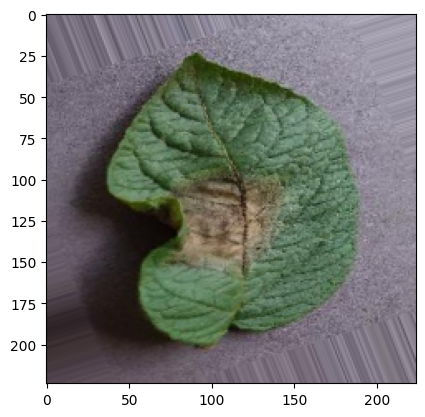

In [17]:
for i,j in train_data:
    plt.imshow( i[0])
    print(class_names[np.argmax(j[0])])
    break

In [18]:
for i,j in train_data:
    print(i.shape,j.shape)
    break

(32, 224, 224, 3) (32, 3)


In [19]:
for i,j in train_data:
    print(i[0],j[0])
    break

[[[0.6730305  0.6259717  0.6338148 ]
  [0.6715923  0.6245335  0.6323766 ]
  [0.67015404 0.6230952  0.63093835]
  ...
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]]

 [[0.6745098  0.627451   0.63529414]
  [0.6745098  0.627451   0.63529414]
  [0.6745098  0.627451   0.63529414]
  ...
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]]

 [[0.6758014  0.6287426  0.6365857 ]
  [0.6745098  0.627451   0.63529414]
  [0.6745098  0.627451   0.63529414]
  ...
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]
  [0.627451   0.58431375 0.60784316]]

 ...

 [[0.45882356 0.40000004 0.41176474]
  [0.47605273 0.4172292  0.4289939 ]
  [0.49411514 0.4352916  0.4470563 ]
  ...
  [0.5112723  0.46421346 0.47989973]
  [0.5242168  0.4771579  0.49284416]
  [0.5199404  0.47288153 0.48856783]]

 [[0.45882356 0.40000004 0.41176474]
  [0.48092556 0.42210203 0.43386674]


In [20]:
s1=pd.Series(train_data.classes)

In [21]:
s1.value_counts()

0    800
1    800
2    484
Name: count, dtype: int64

In [22]:
from tensorflow.keras.applications import VGG16,VGG19

In [23]:
base_model = VGG19(
    weights='imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

In [24]:
for layer in base_model.layers:
    layer.trainable = False

In [25]:
import keras

In [26]:
# model=keras.Sequential([
#     base_model,
#     Flatten(),
#     Dense(256,activation='relu'),
#     Dropout(0.5),
#     Dense(train_data.num_classes,activation='softmax')
# ])

In [27]:
for layer in base_model.layers:
    layer.trainable = False

In [28]:
final_model=keras.Sequential([
    base_model,
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(3,activation='softmax')
])

In [29]:
final_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [30]:
final_model.fit(
    train_data,
    epochs=3,
    validation_data=test_data)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 883s 13s/step - accuracy: 0.6099 - loss: 1.0480 - val_accuracy: 0.8516 - val_loss: 0.4258
Epoch 2/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 856s 13s/step - accuracy: 0.7937 - loss: 0.5108 - val_accuracy: 0.9037 - val_loss: 0.3035
Epoch 3/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 797s 12s/step - accuracy: 0.8642 - loss: 0.3511 - val_accuracy: 0.9306 - val_loss: 0.2211


In [31]:
final_model.evaluate(test_data)

17/17 ━━━━━━━━━━━━━━━━━━━━ 163s 9s/step - accuracy: 0.9268 - loss: 0.2234


[0.22342048585414886, 0.9267822504043579]

In [32]:
y_pred=final_model.predict(test_data)
y_pred1=[np.argmax(i) for i in y_pred]

17/17 ━━━━━━━━━━━━━━━━━━━━ 170s 10s/step


In [33]:
y_test=test_data.classes

In [34]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [35]:
print(confusion_matrix(y_test,y_pred1))

[[192   7   0]
 [ 10 174  16]
 [  2  12 106]]


In [36]:
print(accuracy_score(y_test,y_pred1))

0.9094412331406551


In [37]:
final_model.save('vgg19_potato.keras')

In [38]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array

In [39]:
path=r'C:\Users\Admin\Desktop\img1.png'

In [40]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg19 import preprocess_input
import numpy as np


In [41]:
img2 = load_img(path, target_size=(224,224))   # ✅ FIX SIZE
img2 = img_to_array(img2)

img3 = preprocess_input(img2)                  # ✅ FIX preprocessing

img4 = np.expand_dims(img3, axis=0)

print(img4.shape)

(1, 224, 224, 3)


In [42]:
class_names = list(train_data.class_indices.keys())

prediction = final_model.predict(img4)

print(class_names[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Potato___Late_blight
